# Step 10: Model Interpretation and Explainability

## Purpose
This notebook explains how the final churn models behave globally and locally, with emphasis on trust and practical interpretation.

## What this step answers
- Can we trust the model enough to use its signals?
- Which features drive churn predictions globally?
- How can we explain individual customer predictions?
- Do the interpretable and non-linear models tell a consistent story?

## Models interpreted here
- **Logistic Regression** as the main interpretation model
- **Random Forest** as the comparison model

## Why this step matters
Strong metrics are not enough. If we cannot explain the drivers of churn risk, then trust, actionability, and communication all become weaker.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt

## 1. Rebuild the feature set and split

We rebuild the same cleaned data, feature logic, and data split used in the previous modeling steps.

## Why?
Interpretation must refer to the actual final modeling process. If we changed the feature set here, then the explanations would no longer match the model we evaluated.

In [2]:
PROJECT_DIR = Path.cwd()
CLEANED_FILE = PROJECT_DIR / 'WA_Fn-UseC_-Telco-Customer-Churn-cleaned.csv'
RANDOM_STATE = 42

df = pd.read_csv(CLEANED_FILE)

df['service_count'] = (
    (df['PhoneService'] == 'Yes').astype(int)
    + (df['MultipleLines'] == 'Yes').astype(int)
    + (df['InternetService'] != 'No').astype(int)
    + (df['OnlineSecurity'] == 'Yes').astype(int)
    + (df['OnlineBackup'] == 'Yes').astype(int)
    + (df['DeviceProtection'] == 'Yes').astype(int)
    + (df['TechSupport'] == 'Yes').astype(int)
    + (df['StreamingTV'] == 'Yes').astype(int)
    + (df['StreamingMovies'] == 'Yes').astype(int)
)

df['avg_monthly_value_from_total'] = (df['TotalCharges'] / df['tenure'].replace(0, 1)).round(2)
df['is_new_customer'] = (df['tenure'] <= 12).astype(int)
df['has_long_term_contract'] = df['Contract'].isin(['One year', 'Two year']).astype(int)

X = df.drop(columns=['customerID', 'Churn']).copy()
y = df['Churn'].map({'No': 0, 'Yes': 1}).copy()

categorical_features = X.select_dtypes(include='object').columns.tolist()
numeric_features = X.select_dtypes(exclude='object').columns.tolist()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train_full
)

X_train.shape, X_val.shape, X_test.shape

((4218, 23), (1407, 23), (1407, 23))

## 2. Recreate the final models

We use the same final model settings carried from the evaluation stage.

## Why?
The purpose of interpretation is to explain the actual chosen models, not a simplified placeholder version of them.

In [3]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), numeric_features),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        C=1.0,
        class_weight='balanced',
        solver='lbfgs',
    )),
])

random_forest_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        class_weight='balanced',
    )),
])

logistic_pipeline.fit(X_train, y_train)
random_forest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

## 3. Global interpretation for Logistic Regression

For Logistic Regression, the most natural global explanation is the coefficient table.

## Why?
Each coefficient tells us how a feature moves the prediction toward or away from churn, after preprocessing. This makes Logistic Regression especially valuable for an interpretation-first project.

In [4]:
feature_names = logistic_pipeline.named_steps['preprocessor'].get_feature_names_out()
logistic_model = logistic_pipeline.named_steps['model']

logistic_importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': logistic_model.coef_[0],
})
logistic_importance_df['abs_coefficient'] = logistic_importance_df['coefficient'].abs()

top_positive_logistic = logistic_importance_df.sort_values(by='coefficient', ascending=False).head(15)
top_negative_logistic = logistic_importance_df.sort_values(by='coefficient', ascending=True).head(15)

top_positive_logistic

,feature,coefficient,abs_coefficient
20,categorical__InternetService_Fiber optic,0.638832,0.638832
6,numeric__is_new_customer,0.333955,0.333955
3,numeric__TotalCharges,0.271221,0.271221
22,categorical__OnlineSecurity_No,0.258071,0.258071
4,numeric__service_count,0.241824,0.241824
31,categorical__TechSupport_No,0.232703,0.232703
47,categorical__PaymentMethod_Electronic check,0.203726,0.203726
39,categorical__StreamingMovies_Yes,0.196225,0.196225
41,categorical__Contract_One year,0.190697,0.190697
40,categorical__Contract_Month-to-month,0.163128,0.163128


In [5]:
top_negative_logistic

,feature,coefficient,abs_coefficient
1,numeric__tenure,-0.663287,0.663287
19,categorical__InternetService_DSL,-0.585814,0.585814
2,numeric__MonthlyCharges,-0.542050,0.542050
42,categorical__Contract_Two year,-0.494567,0.494567
7,numeric__has_long_term_contract,-0.482430,0.482430
16,categorical__MultipleLines_No,-0.237983,0.237983
46,categorical__PaymentMethod_Credit card (automa...,-0.226657,0.226657
13,categorical__Dependents_Yes,-0.209493,0.209493
24,categorical__OnlineSecurity_Yes,-0.205053,0.205053
21,categorical__InternetService_No,-0.193760,0.193760


## 4. Global interpretation for Random Forest

For Random Forest, we use feature importance as a global summary.

## Why?
Random Forest does not give simple signed coefficients like Logistic Regression. Feature importance tells us which variables the forest relied on most across many tree splits.

In [6]:
rf_model = random_forest_pipeline.named_steps['model']
rf_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_,
}).sort_values(by='importance', ascending=False)

rf_importance_df.head(20)

,feature,importance
40,categorical__Contract_Month-to-month,0.139790
7,numeric__has_long_term_contract,0.112122
1,numeric__tenure,0.092268
3,numeric__TotalCharges,0.067114
22,categorical__OnlineSecurity_No,0.061251
5,numeric__avg_monthly_value_from_total,0.051209
2,numeric__MonthlyCharges,0.050366
42,categorical__Contract_Two year,0.047962
31,categorical__TechSupport_No,0.045576
20,categorical__InternetService_Fiber optic,0.043538


## 5. Compare the models' global stories

Now we compare whether both models point toward similar churn drivers.

## Why?
When two different model families highlight similar features, our confidence in those drivers increases.

In [7]:
comparison_df = logistic_importance_df[['feature', 'abs_coefficient']].merge(
    rf_importance_df[['feature', 'importance']],
    on='feature',
    how='inner'
).sort_values(by=['abs_coefficient', 'importance'], ascending=False)

comparison_df.head(20)

,feature,abs_coefficient,importance
1,numeric__tenure,0.663287,0.092268
20,categorical__InternetService_Fiber optic,0.638832,0.043538
19,categorical__InternetService_DSL,0.585814,0.012994
2,numeric__MonthlyCharges,0.542050,0.050366
42,categorical__Contract_Two year,0.494567,0.047962
7,numeric__has_long_term_contract,0.482430,0.112122
6,numeric__is_new_customer,0.333955,0.036596
3,numeric__TotalCharges,0.271221,0.067114
22,categorical__OnlineSecurity_No,0.258071,0.061251
4,numeric__service_count,0.241824,0.014005


## 6. Local explanation for individual customers using Logistic Regression

We explain a few individual predictions by breaking the prediction into feature contributions.

## Why?
Global importance answers, 'what usually matters?' Local explanation answers, 'why was this specific customer predicted as a churn risk?'

In [8]:
X_test_transformed = logistic_pipeline.named_steps['preprocessor'].transform(X_test)
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()

logistic_scores = logistic_pipeline.predict_proba(X_test)[:, 1]
local_cases = X_test.copy()
local_cases['actual'] = y_test.values
local_cases['predicted_probability'] = logistic_scores

high_risk_cases = local_cases.sort_values(by='predicted_probability', ascending=False).head(3)
high_risk_cases[['actual', 'predicted_probability']]

,actual,predicted_probability
2626,1,0.950797
3374,1,0.950789
3154,0,0.950422


In [9]:
def explain_logistic_case(case_index):
    case_position = X_test.index.get_loc(case_index)
    contributions = X_test_transformed[case_position] * logistic_model.coef_[0]
    explanation_df = pd.DataFrame({
        'feature': feature_names,
        'contribution': contributions,
    })
    explanation_df['abs_contribution'] = explanation_df['contribution'].abs()

    return explanation_df.sort_values(by='abs_contribution', ascending=False).head(15)

explain_logistic_case(high_risk_cases.index[0])

,feature,contribution,abs_contribution
1,numeric__tenure,0.688162,0.688162
20,categorical__InternetService_Fiber optic,0.638832,0.638832
2,numeric__MonthlyCharges,-0.620647,0.620647
6,numeric__is_new_customer,0.499499,0.499499
7,numeric__has_long_term_contract,0.438867,0.438867
22,categorical__OnlineSecurity_No,0.258071,0.258071
31,categorical__TechSupport_No,0.232703,0.232703
0,numeric__SeniorCitizen,0.229710,0.229710
47,categorical__PaymentMethod_Electronic check,0.203726,0.203726
39,categorical__StreamingMovies_Yes,0.196225,0.196225


## 7. Global behavior analysis with partial dependence

We inspect how predicted churn risk changes as important numeric features vary.

## Why?
Feature importance tells us *what matters*. Partial dependence helps us ask *how the prediction changes* as a feature changes.

In [10]:
numeric_candidates = [feature for feature in ['tenure', 'MonthlyCharges', 'TotalCharges', 'service_count'] if feature in X_train.columns]
numeric_candidates

['tenure', 'MonthlyCharges', 'TotalCharges', 'service_count']

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 4 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


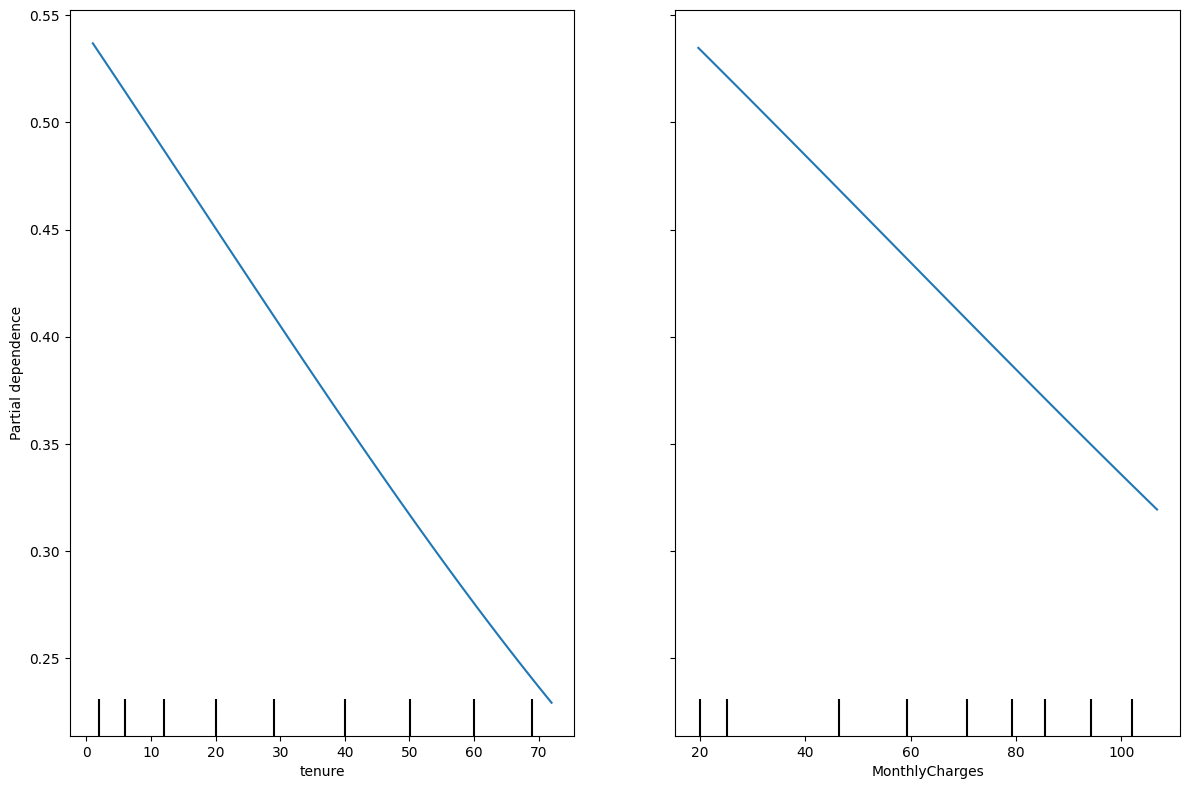

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    logistic_pipeline,
    X_train,
    features=numeric_candidates[:2],
    ax=ax,
)
plt.tight_layout()

## 8. Trust checklist

Use the interpretation outputs to answer these trust questions:

- Do the most important features make business sense?
- Do Logistic Regression and Random Forest broadly agree on the main drivers?
- Do the local explanations for risky customers look reasonable?
- Do the partial dependence patterns match domain intuition?

If the answers are mostly yes, then trust in the model improves. If not, interpretation becomes a warning tool rather than just a reporting tool.

## 9. What to bring back to me

After you run this notebook, bring me:
- `top_positive_logistic`
- `top_negative_logistic`
- `rf_importance_df.head(20)`
- one local explanation table from `explain_logistic_case(...)`
- your interpretation of the partial dependence plots

Then I will help you turn those outputs into a proper explanation report.